In [413]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [414]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/google_colab/spotify_tracks_dataset_114k.csv'
df = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Column Description

- **track_id**: The Spotify ID for the track
- **artists**: The artists' names who performed the track. If there is more than one artist, they are separated by a `;`
- **album_name**: The album name in which the track appears
- **track_name**: Name of the track
- **popularity**: The popularity of a track is a value between 0 and 100, with 100 being the most popular. The popularity is calculated by algorithm and is based, in the most part, on the total number of plays the track has had and how recent those plays are. Generally speaking, songs that are being played a lot now will have a higher popularity than songs that were played a lot in the past. Duplicate tracks (e.g. the same track from a single and an album) are rated independently. Artist and album popularity is derived mathematically from track popularity.
- **duration_ms**: The track length in milliseconds
- **explicit**: Whether or not the track has explicit lyrics (true = yes it does; false = no it does not OR unknown)
- **danceability**: Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable
- **energy**: Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale
- **key**: The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1
- **loudness**: The overall loudness of a track in decibels (dB)
- **mode**: Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0
- **speechiness**: Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks
- **acousticness**: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic
- **instrumentalness**: Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content
- **liveness**: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live
- **valence**: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)
- **tempo**: The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration
- **time_signature**: An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.
- **track_genre**: The genre in which the track belongs

In [415]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [416]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [417]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [418]:
df.shape

(114000, 21)

In [419]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [420]:
df.dtypes

,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64


In [421]:
# data = data.drop(columns=["Unnamed: 0"])
df = df.dropna(subset=["artists", "track_name"])
print("tracks: %d" % len(df))

tracks: 113999


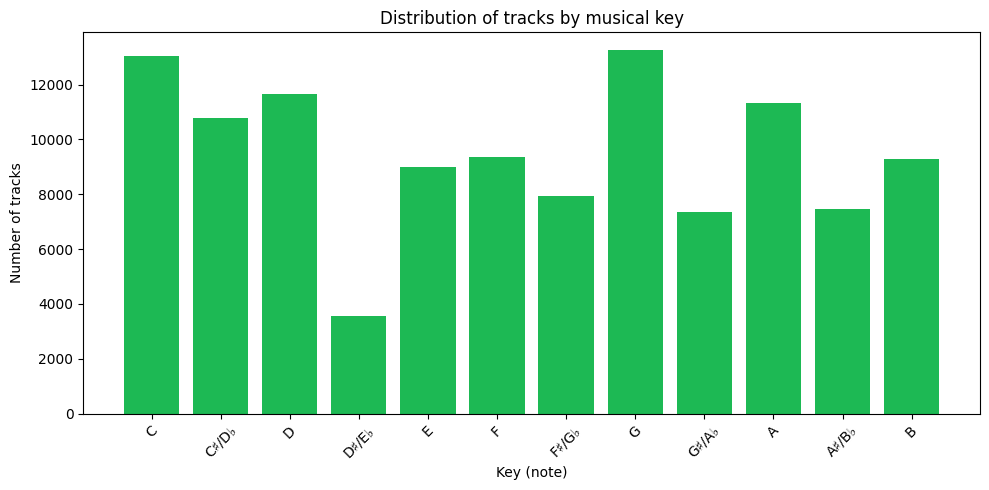

In [422]:
# Pitch class -> note name (index 0..11), per the column description
notes = ['C', 'C♯/D♭', 'D', 'D♯/E♭', 'E', 'F',
         'F♯/G♭', 'G', 'G♯/A♭', 'A', 'A♯/B♭', 'B']

# Count tracks per key, ordered 0..11; drop -1 ("no key detected")
counts = df["key"].value_counts().sort_index()
counts = counts[counts.index >= 0]

plt.figure(figsize=(10, 5))
plt.bar([notes[k] for k in counts.index], counts.values, color="#1DB954")
plt.xlabel("Key (note)")
plt.ylabel("Number of tracks")
plt.title("Distribution of tracks by musical key")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

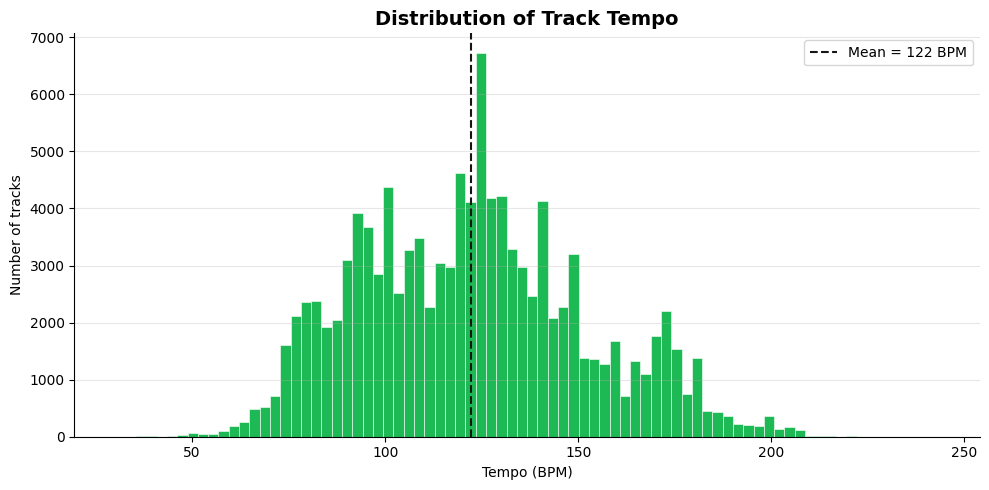

In [423]:
# Drop tempo == 0 (undetected/bad values that pile up at the far left)
tempo = df.loc[df["tempo"] > 0, "tempo"]
mean_tempo = tempo.mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tempo, bins=80, color="#1DB954", edgecolor="white", linewidth=0.4)

# Mean reference line
ax.axvline(mean_tempo, color="#191414", linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_tempo:.0f} BPM")

ax.set_title("Distribution of Track Tempo", fontsize=14, fontweight="bold")
ax.set_xlabel("Tempo (BPM)")
ax.set_ylabel("Number of tracks")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [424]:
df["duration_min"] = df["duration_ms"] / 60000

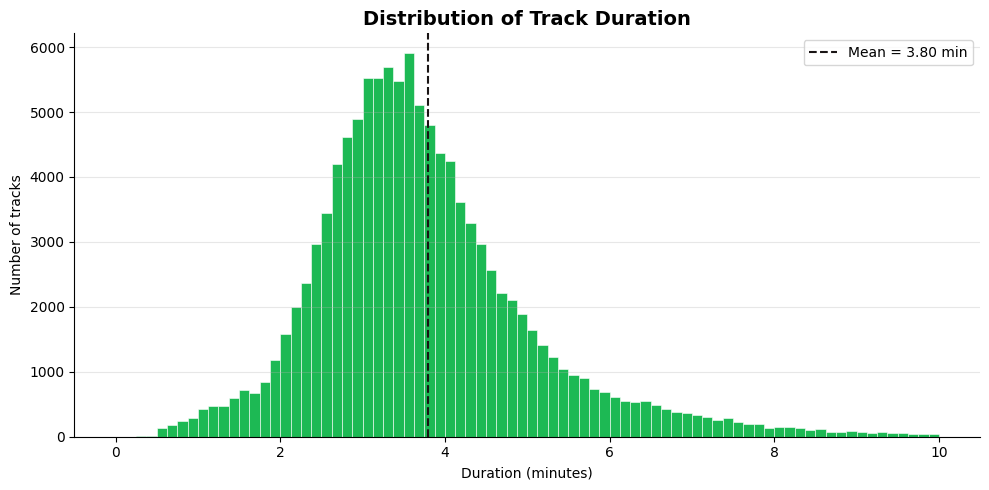

In [425]:
# graph for duration in minutes
# Keep real durations; clip the long tail (a few tracks run >10 min) so the
# bulk of the distribution stays readable
duration_min = df.loc[df["duration_min"] > 0, "duration_min"]
mean_min = duration_min.mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(duration_min, bins=80, range=(0, 10),
        color="#1DB954", edgecolor="white", linewidth=0.4)

# Mean reference line
ax.axvline(mean_min, color="#191414", linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_min:.2f} min")

ax.set_title("Distribution of Track Duration", fontsize=14, fontweight="bold")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Number of tracks")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

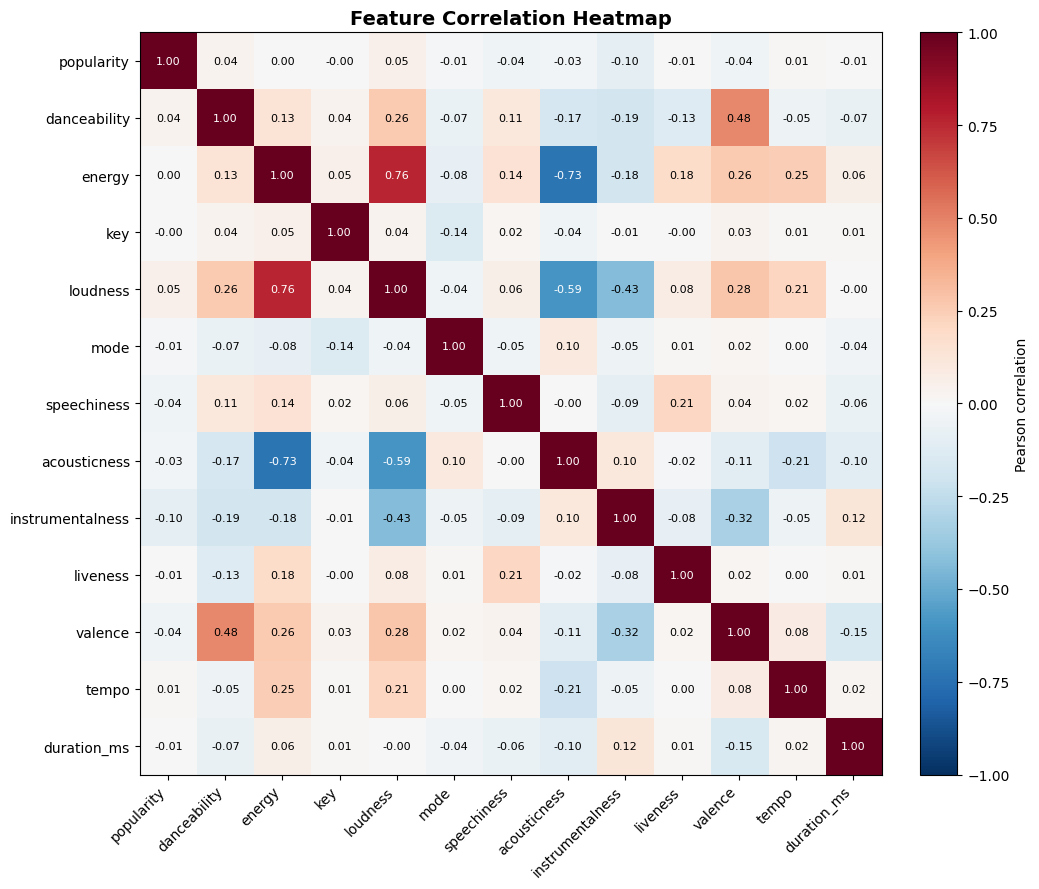

In [426]:
# correlation heatmap to choose good features
# Strongly correlated features are redundant for clustering; this helps spot them.
heatmap_cols = ['popularity', 'danceability', 'energy', 'key', 'loudness', 'mode',
                'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                'valence', 'tempo', 'duration_ms']

corr = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

# Ticks / labels
ax.set_xticks(range(len(heatmap_cols)))
ax.set_yticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=45, ha="right")
ax.set_yticklabels(heatmap_cols)

# Annotate each cell with its correlation value
for i in range(len(heatmap_cols)):
    for j in range(len(heatmap_cols)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.5 else "black", fontsize=8)

ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson correlation")
plt.tight_layout()
plt.show()



In [427]:
# Feature selection for clustering.
# We keep the audio "character" features and drop `key` and `mode`:
# the heatmap above shows `key` has ~0 correlation with everything, and both are
# nominal/cyclical codes (0-11, 0/1) that only add noise to a Euclidean KMeans.
feature_columns = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness',
                   'valence', 'tempo']

# IMPORTANT: keep the full `df` intact (we need track_genre/track_name later to
# interpret the clusters). Build a separate feature matrix instead of overwriting df.
X = df[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 0.62923855, -0.71714698,  0.300825  , ...,  0.75873531,
         0.92931467, -1.14185449],
       [-0.84590813, -1.88997393, -1.78473883, ..., -0.59121587,
        -0.79868091, -1.48970775],
       [-0.74218688, -1.12266681, -0.29328928, ..., -0.50717222,
        -1.36567947, -1.52830252],
       ...,
       [ 0.35841084, -1.24193735, -0.52413489, ..., -0.68103752,
         1.0373144 ,  0.34125863],
       [ 0.11639459, -0.53824118, -0.52294189, ...,  0.29649522,
        -0.23553949,  0.46074562],
       [-0.23510521, -0.61377919, -0.38674099, ..., -0.65267279,
         0.90231474, -1.43269958]])

In [428]:
inertia_values = []

for k in range(1, 15):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

inertia_values

[1025990.9999999946,
 805666.5090331729,
 736199.7078182169,
 651682.7507749901,
 595896.936119414,
 546136.9248846354,
 484087.33201293263,
 456426.2147321532,
 430864.2770638259,
 413281.8484588813,
 399474.77194014937,
 386931.32653784985,
 375032.2702930536,
 363319.47377368034]

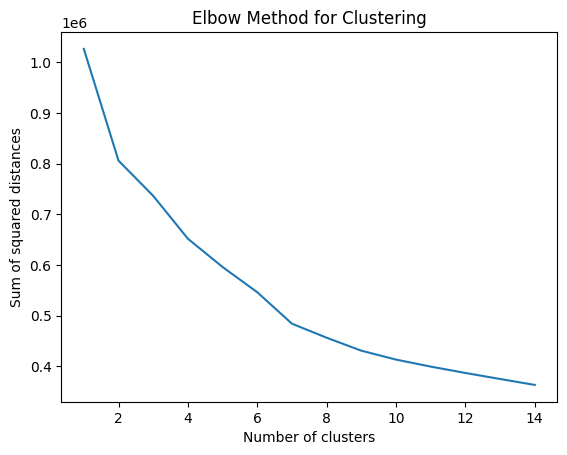

In [429]:
plt.plot(range(1, 15), inertia_values)
plt.title('Elbow Method for Clustering')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of squared distances')
plt.show()

In [430]:
optimal_k = 8
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_scaled)
clusters = cluster_labels                      # alias kept for older cells below
cluster_centers = kmeans_model.cluster_centers_

# Attach labels to the full dataframe so we can profile clusters by audio
# features AND by metadata (genre, track name) further down.
df['Cluster'] = cluster_labels

df[['track_name', 'artists', 'track_genre'] + feature_columns + ['Cluster']].head()

,track_name,artists,track_genre,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster
0,Comedy,Gen Hoshino,acoustic,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,1
1,Ghost - Acoustic,Ben Woodward,acoustic,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,2
2,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,2
3,Can't Help Falling In Love,Kina Grannis,acoustic,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,2
4,Hold On,Chord Overstreet,acoustic,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,2


In [431]:
# Silhouette score on a random sample (the full 114k is too slow for silhouette).
# Closer to 1 = well-separated clusters; near 0 = overlapping.
import numpy as np
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), size=10000, replace=False)
sil = silhouette_score(X_scaled[sample_idx], cluster_labels[sample_idx])
print(f"Silhouette score (k={optimal_k}, 10k sample): {sil:.3f}")

Silhouette score (k=8, 10k sample): 0.203


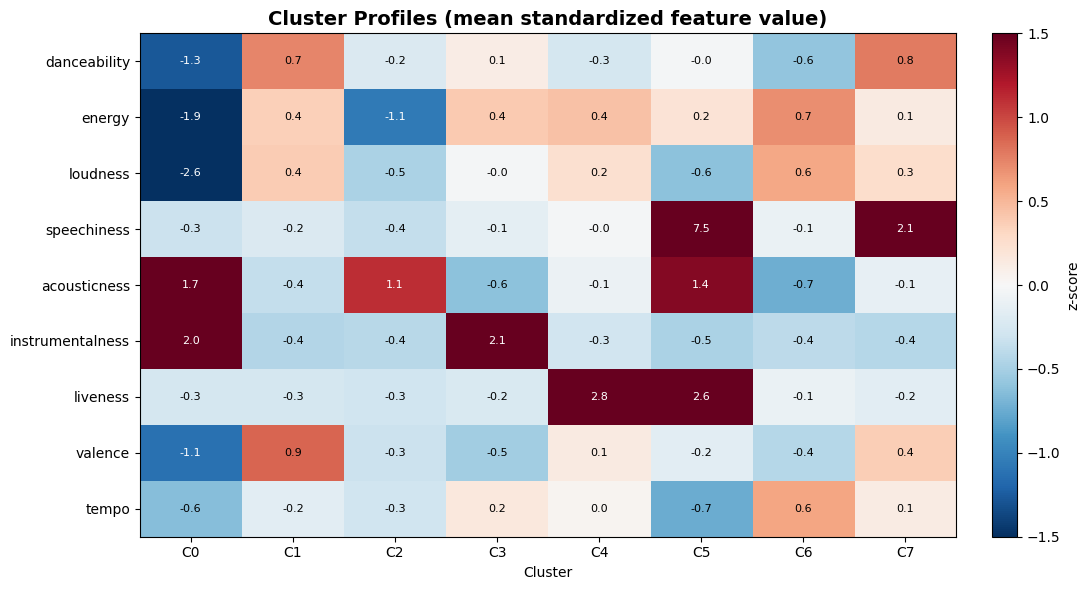

In [432]:
# Cluster profile: mean *standardized* value of each feature per cluster.
# Red = well above average for that feature, blue = well below. This is what
# makes each cluster "interesting" — it tells you the personality of each group.
profile = pd.DataFrame(X_scaled, columns=feature_columns)
profile['Cluster'] = cluster_labels
cluster_means = profile.groupby('Cluster').mean()

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(cluster_means.T, cmap='RdBu_r', vmin=-1.5, vmax=1.5, aspect='auto')

ax.set_xticks(range(optimal_k))
ax.set_xticklabels([f'C{c}' for c in cluster_means.index])
ax.set_yticks(range(len(feature_columns)))
ax.set_yticklabels(feature_columns)

for i in range(len(feature_columns)):
    for j in range(optimal_k):
        val = cluster_means.iloc[j, i]
        ax.text(j, i, f"{val:.1f}", ha='center', va='center', fontsize=8,
                color='white' if abs(val) > 0.9 else 'black')

ax.set_title('Cluster Profiles (mean standardized feature value)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='z-score')
plt.tight_layout()
plt.show()

### Visualize the generated clusters

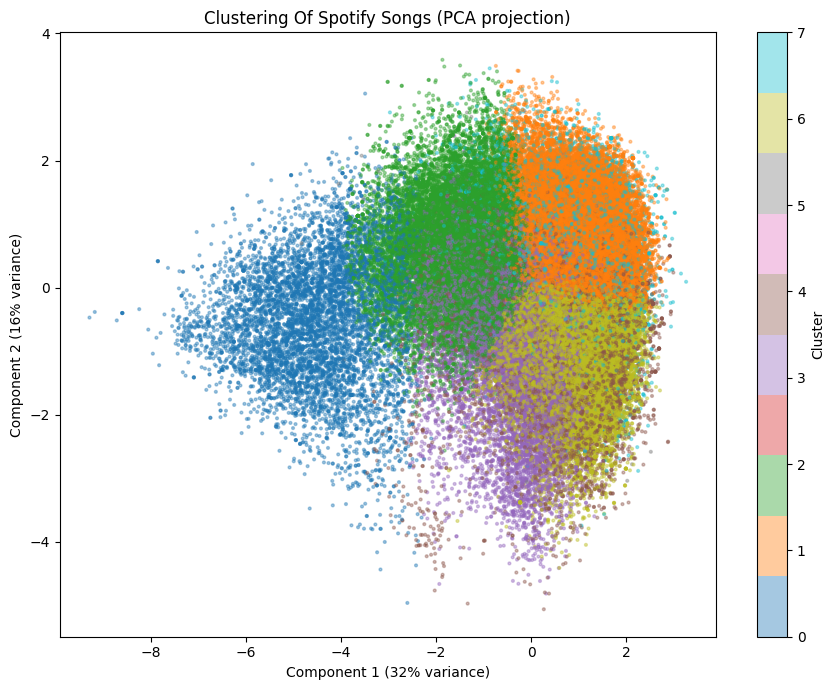

In [433]:
# PCA on the SCALED feature matrix (not the raw df, and NOT the Cluster column).
# This projects the 9 audio features down to 2D just for visualization.
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(9, 7))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels,
                 cmap='tab10', s=4, alpha=0.4)
plt.title('Clustering Of Spotify Songs (PCA projection)')
plt.xlabel(f'Component 1 ({var[0]:.0f}% variance)')
plt.ylabel(f'Component 2 ({var[1]:.0f}% variance)')
plt.colorbar(sc, label='Cluster', ticks=range(optimal_k))
plt.tight_layout()
plt.show()

### Each cluster in its own graph

The combined scatter above gets crowded, so below we highlight one cluster at a
time (its points colored, the rest greyed out) using the same PCA projection.

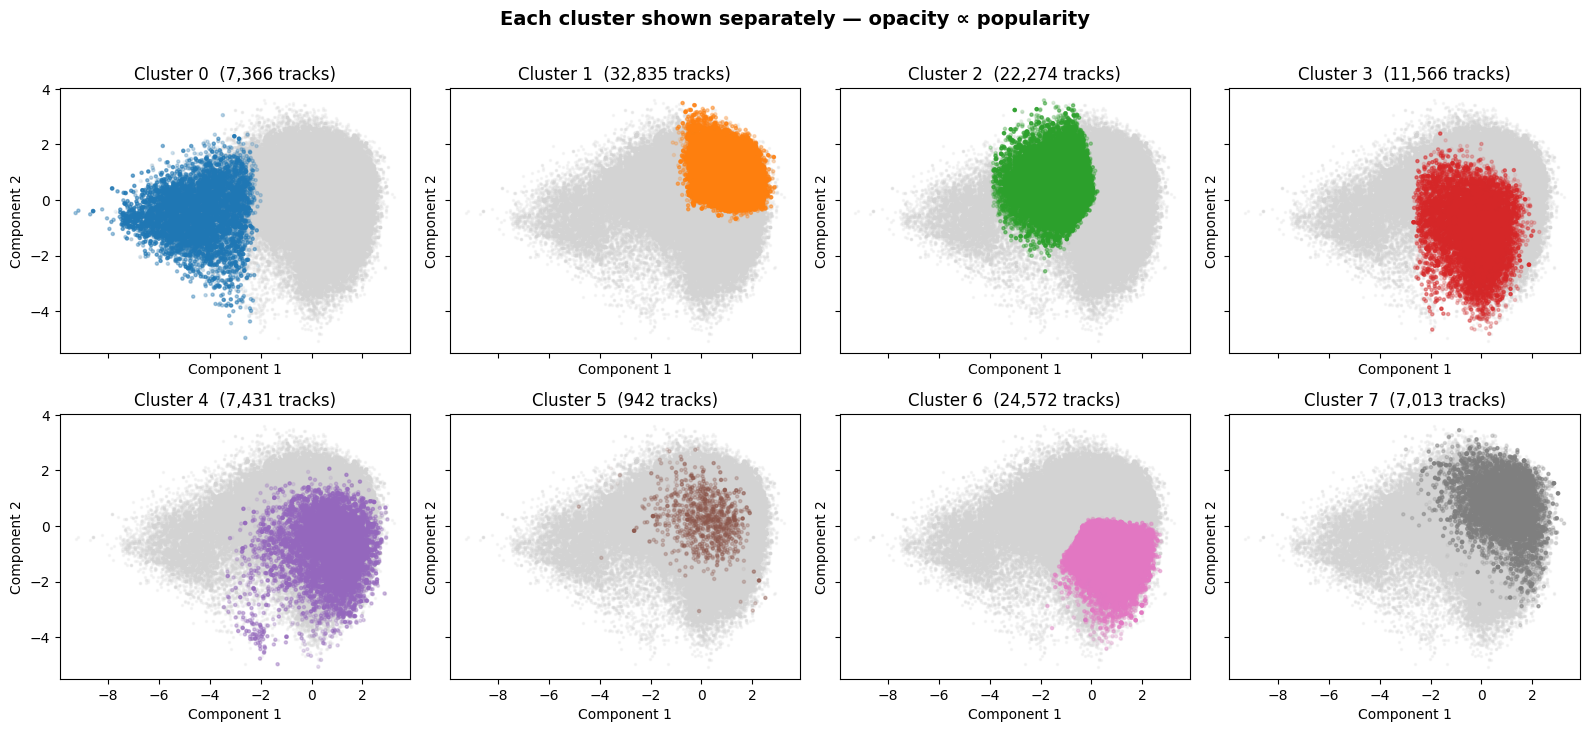

In [434]:
# One subplot per cluster on the shared PCA projection.
# Point opacity scales with popularity: the most popular tracks show up solid,
# obscure ones fade into the background.
ncols = 4
nrows = int(np.ceil(optimal_k / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.6 * nrows),
                         sharex=True, sharey=True)
axes = axes.ravel()

# Map popularity (0-100) -> alpha in [0.05, 1.0].
pop = df['popularity'].to_numpy()
point_alpha = 0.05 + 0.95 * (pop / 100.0)

for c in range(optimal_k):
    ax = axes[c]
    # grey background = all other points (kept faint and uniform)
    ax.scatter(coords[:, 0], coords[:, 1], s=2, color='lightgray', alpha=0.2)

    mask = cluster_labels == c
    # bake per-point alpha into RGBA so each dot fades by its own popularity,
    # then draw most-popular last so they sit on top
    order = np.argsort(point_alpha[mask])
    idx = np.flatnonzero(mask)[order]
    rgba = np.tile(plt.cm.tab10(c % 10), (idx.size, 1))
    rgba[:, 3] = point_alpha[idx]
    ax.scatter(coords[idx, 0], coords[idx, 1], s=5, color=rgba)

    ax.set_title(f'Cluster {c}  ({mask.sum():,} tracks)')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

# hide any unused axes
for j in range(optimal_k, len(axes)):
    axes[j].axis('off')

fig.suptitle('Each cluster shown separately — opacity ∝ popularity',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

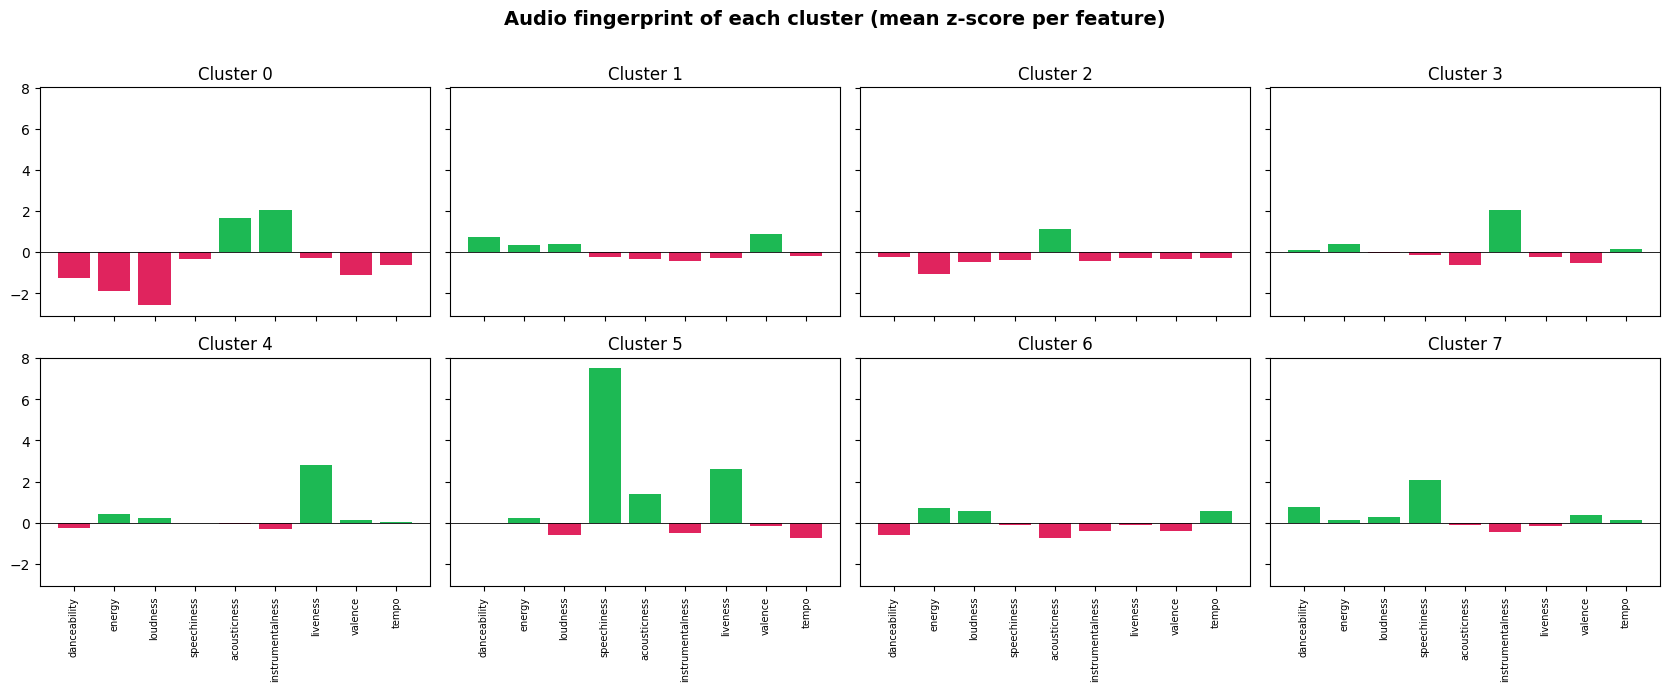

In [435]:
# Each cluster's audio "fingerprint" in its own bar chart (mean standardized
# feature values). Bars above 0 = above the dataset average, below 0 = under it.
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows),
                         sharex=True, sharey=True)
axes = axes.ravel()

for c in range(optimal_k):
    ax = axes[c]
    vals = cluster_means.loc[c]
    colors = ['#1DB954' if v >= 0 else '#E0245E' for v in vals]
    ax.bar(range(len(feature_columns)), vals, color=colors)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f'Cluster {c}')
    ax.set_xticks(range(len(feature_columns)))
    ax.set_xticklabels(feature_columns, rotation=90, fontsize=7)

for j in range(optimal_k, len(axes)):
    axes[j].axis('off')

fig.suptitle('Audio fingerprint of each cluster (mean z-score per feature)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [436]:
# Interpret the clusters: size, the 2 most extreme audio traits, and the top
# genres falling into each. This is what turns "Cluster 3" into a description.
summary = []
for c in range(optimal_k):
    m = cluster_means.loc[c]
    hi = m.sort_values(ascending=False).head(2).index.tolist()   # strongest traits
    lo = m.sort_values().head(2).index.tolist()                  # weakest traits
    top_genres = (df.loc[df['Cluster'] == c, 'track_genre']
                    .value_counts().head(3).index.tolist())
    summary.append({
        'Cluster': c,
        'Size': int((cluster_labels == c).sum()),
        'High in': ', '.join(hi),
        'Low in': ', '.join(lo),
        'Top genres': ', '.join(top_genres),
    })

summary_df = pd.DataFrame(summary).set_index('Cluster')
summary_df

,Size,High in,Low in,Top genres
Cluster,,,,
0,7366,"instrumentalness, acousticness","loudness, energy","new-age, sleep, classical"
1,32835,"valence, danceability","instrumentalness, acousticness","salsa, latino, reggaeton"
2,22274,"acousticness, danceability","energy, loudness","romance, honky-tonk, tango"
3,11566,"instrumentalness, energy","acousticness, valence","minimal-techno, detroit-techno, techno"
4,7431,"liveness, energy","instrumentalness, danceability","pagode, sertanejo, samba"
5,942,"speechiness, liveness","tempo, loudness","comedy, kids, show-tunes"
6,24572,"energy, tempo","acousticness, danceability","metalcore, heavy-metal, grunge"
7,7013,"speechiness, danceability","instrumentalness, liveness","j-dance, dancehall, funk"


In [437]:
# Top 10 tracks by popularity within each cluster, laid out as a (Cluster, Rank) table.
# The dataset stores the same song once per genre, so a track can repeat (e.g.
# "La Bachata" across latino/reggae/...). Collapse to one row per
# (track_name, artists), keeping its most popular copy, before ranking.
deduped = (
    df.sort_values('popularity', ascending=False)
      .drop_duplicates(subset=['track_name', 'artists'], keep='first')
)

top_per_cluster = (
    deduped
      .groupby('Cluster', group_keys=False)
      .head(2)
      .sort_values(['Cluster', 'popularity'], ascending=[True, False])
      .copy()
)

# Rank 1..10 inside each cluster.
top_per_cluster['Rank'] = top_per_cluster.groupby('Cluster').cumcount() + 1

top_table = top_per_cluster.set_index(['Cluster', 'Rank'])[
    ['track_name', 'artists', 'track_genre', 'popularity']
]

# Show the whole thing (all 8 clusters x 10 rows) without pandas truncating.
with pd.option_context('display.max_rows', None):
    display(top_table)

track_name  \
Cluster Rank                                              
0       1                           everything i wanted   
        2     Clean White Noise - Loopable with no fade   
1       1         Quevedo: Bzrp Music Sessions, Vol. 52   
        2                                    La Bachata   
2       1                                 Glimpse of Us   
        2                                  Another Love   
3       1                                        Freaks   
        2                                    Apocalypse   
4       1                                 Ojitos Lindos   
        2                                         Tarot   
5       1                         Chop (Nouvelle École)   
        2                                Alone With You   
6       1                     Unholy (feat. Kim Petras)   
        2                               I'm Good (Blue)   
7       1                              Tití Me Preguntó   
        2                             Super Freaky Girl   

                                                    artists track_genre  \
Cluster Rank                                                              
0       1                                     Billie Eilish     electro   
        2     White Noise Baby Sleep;White Noise for Babies       sleep   
1       1                                  Bizarrap;Quevedo     hip-hop   
        2                                     Manuel Turizo      reggae   
2       1                                              Joji         pop   
        2                                         Tom Odell       chill   
3       1                                        Surf Curse        punk   
        2                              Cigarettes After Sex   indie-pop   
4       1                           Bad Bunny;Bomba Estéreo      latino   
        2                                  Bad Bunny;Jhayco      latino   
5       1                                             Fresh      french   
        2                                               Arz       chill   
6       1                              Sam Smith;Kim Petras       dance   
        2                           David Guetta;Bebe Rexha         edm   
7       1                                         Bad Bunny      latino   
        2                                       Nicki Minaj       dance   

              popularity  
Cluster Rank              
0       1             86  
        2             85  
1       1             99  
        2             98  
2       1             94  
        2             93  
3       1             86  
        2             84  
4       1             95  
        2             91  
5       1             76  
        2             73  
6       1            100  
        2             98  
7       1             97  
        2             92